
# 11 — Tuning, and what it was worth

Every number this project has produced so far comes from a model at its **defaults**.
Thirty epochs, batch 32 and learning rate 1e-3 were inherited from the original study's
notebooks. `n_estimators=300, max_depth=12` was picked by hand. So every ranking has
really been a ranking of *whose defaults happen to suit this data*, which is a weaker
claim than it looks and a different question from which model is better.

This notebook removes that variable. It reads the results of
`experiments/run_tuning.py`, which takes hours, rather than re-running the search — the
search itself is the expensive part and there is nothing to be gained by repeating it in
a notebook.

## The protocol, and why it is shaped this way

Nested search inside all eight evaluation folds is the gold standard and is unaffordable
here: roughly fourteen models × two operators × eight folds × thirty trials. What is
affordable and still leak-free:

1. Take the **development prefix** — everything before the first evaluation fold's test
   block.
2. Run an **inner rolling-origin schedule inside that prefix only**, so selection is
   itself rolling-origin rather than a single split.
3. **Random search, 30 trials, fixed seed.** Random rather than grid on Bergstra &
   Bengio's argument that most hyperparameters do not matter, so at equal budget random
   search covers the ones that do far better than a grid.
4. Freeze the winner and score it on the **untouched** evaluation folds.

> **The boundary is a timestamp, not a row count.** A trial may ask for `lookback=48`,
> which drops more warm-up rows and shortens the design matrix. With a row count, "the
> first 40%" would slide further into the series and quietly start selecting on
> evaluation data. `test_tuning_prefix_ends_before_the_first_test_block` and
> `test_tuning_prefix_holds_when_a_trial_changes_the_lookback` pin both halves of that.

## The feature set is in the search space

`lookback`, `covariates` and `context` are searched alongside learning rate and tree
depth. That is deliberate. This project's own finding is that lag depth mattered more
than architecture, so holding depth fixed at 24 while tuning everything else would bake
in exactly the assumption under test. It also means **"do the covariates earn anything?"
is settled by measurement** — a model that is better without them gets tuned to drop
them, visibly, in a table.

Optuna's TPE would be the obvious alternative and is deliberately not used: a seeded
30-trial random search needs no dependency, and adding one would break the "clone it on
Kaggle and run, no installs" property `docs/KAGGLE.md` promises.

In [1]:
# --- Bootstrap: works locally, on Colab and on Kaggle ----------------------
# RUN THIS CELL FIRST, and re-run it after any kernel restart. Every later cell
# depends on it. If it fails, the next cell fails with "No module named bwalloc",
# which looks like a different problem but is not.
#
# On a hosted runtime it clones the repo (or pulls, on a re-run) and installs the
# package into the session, so `import bwalloc` keeps working even from a cell you
# run on its own after restarting. The repository is public; no token is needed.
import os, subprocess, sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
REPO = "https://github.com/sad-code-at/bwalloc.git"

def _find_root(start: Path):
    node = start
    while not (node / "src" / "bwalloc").exists() and node != node.parent:
        node = node.parent
    return node if (node / "src" / "bwalloc").exists() else None

ROOT = _find_root(Path.cwd())

if ROOT is None:
    # A repo uploaded as a Kaggle Dataset mounts read-only here; prefer it if present.
    for candidate in Path("/kaggle/input").glob("*/src/bwalloc"):
        ROOT = candidate.parent.parent
        break

if ROOT is None:
    on_kaggle = Path("/kaggle/working").exists()
    target = Path("/kaggle/working/bwalloc") if on_kaggle else Path("/content/bwalloc")
    if _find_root(target) is None:
        if os.system("git clone -q " + REPO + " " + str(target)) != 0 or _find_root(target) is None:
            raise RuntimeError(
                "Clone failed. On Kaggle, switch Internet ON in the right sidebar "
                "(Settings > Internet), then re-run this cell. See docs/KAGGLE.md."
            )
        print("cloned", REPO)
    else:
        os.system("git -C " + str(target) + " pull -q --ff-only")
        print("pulled latest into", target)
    os.chdir(target)
    ROOT = target
    # Install into the session so `import bwalloc` survives a kernel restart and
    # does not depend on this cell having set sys.path. --no-deps deliberately:
    # Kaggle and Colab curate their own numpy/pandas and we must not disturb them.
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", ".", "--no-deps"],
                   cwd=str(ROOT), capture_output=True)

sys.path.insert(0, str(ROOT / "src"))

try:
    import xgboost  # noqa: F401
except ImportError:
    !pip install -q xgboost

import numpy as np, pandas as pd, matplotlib.pyplot as plt
import bwalloc as bw
from bwalloc.plots import use_paper_style

bw.set_seed()
use_paper_style()
pd.set_option("display.width", 200)
RESULTS = ROOT / "experiments" / "results"
# Scratch output for the exploratory notebooks. Only 07_paper_figures writes into
# paper/figures -- otherwise running notebook 00 or 05 silently overwrites a figure
# the paper cites, which is exactly the kind of drift this project exists to remove.
FIGURES = ROOT / "notebooks" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
_data = sorted((ROOT / "data").glob("*.csv"))
_res = sorted(RESULTS.glob("*.csv"))
print("bwalloc", bw.__version__, "at", ROOT)
print(f"  data/    {len(_data)} csv  ({', '.join(f.name for f in _data) or 'MISSING'})")
print(f"  results/ {len(_res)} csv")
if not _data:
    raise RuntimeError(
        "The trace CSVs are missing, so nothing will run. Re-run this cell to "
        "re-clone, or check that the repository was fetched completely."
    )

bwalloc 0.1.0 at D:\L4-T-1\EEE 402\project\bwalloc
  data/    2 csv  (gp_dhaka.csv, robi_dhaka3.csv)
  results/ 77 csv


## The boundary, checked rather than asserted

In [2]:

from bwalloc.data import load, sampling_profile
from bwalloc.features import build_features
from bwalloc.sequence import full_feature_config
from bwalloc.splits import rolling_origin
from bwalloc.tuning import (FEATURE_SPACE, SEARCH_SPACES, development_cutoff,
                            development_slice, feature_config_for)

OPERATOR = "gp"          # switch to "robi" and re-run

df = load(OPERATOR)
profile = sampling_profile(df)
X_ref, y_ref = build_features(df, profile, full_feature_config(24, covariates=True))
cutoff = development_cutoff(pd.DatetimeIndex(X_ref.index), n_folds=8)
folds = rolling_origin(len(X_ref), n_folds=8)
first_test = pd.Timestamp(X_ref.index[folds[0].test[0]])

print(f"development prefix ends      {cutoff}")
print(f"first evaluation test block  {first_test}")
print(f"overlap: {'NONE' if cutoff <= first_test else 'YES — PROTOCOL VOID'}")

rows = []
for lookback in (8, 12, 24, 36, 48):
    Xl, yl = build_features(df, profile, feature_config_for(
        {"lookback": lookback, "covariates": True, "context": "all"}))
    Xd, _ = development_slice(Xl, yl, cutoff)
    rows.append({"lookback": lookback, "design_rows": len(Xl),
                 "prefix_rows": len(Xd),
                 "last_prefix_timestamp": pd.DatetimeIndex(Xd.index).max(),
                 "before_first_test": pd.DatetimeIndex(Xd.index).max() < first_test})
pd.DataFrame(rows)

development prefix ends      2025-04-27 04:42:00
first evaluation test block  2025-04-27 04:42:00
overlap: NONE


,lookback,design_rows,prefix_rows,last_prefix_timestamp,before_first_test
0,8,888,359,2025-04-27 03:17:00,True
1,12,888,359,2025-04-27 03:17:00,True
2,24,881,352,2025-04-27 03:17:00,True
3,36,869,340,2025-04-27 03:17:00,True
4,48,857,328,2025-04-27 03:17:00,True



The `prefix_rows` column shrinks as the lookback deepens — that is the warm-up being
dropped — while `last_prefix_timestamp` stays put. That is the whole reason the boundary
is expressed in wall-clock time.

## The search space

In [3]:

print("shared by every model (the feature set is a hyperparameter here):")
for k, v in FEATURE_SPACE.items():
    print(f"  {k:12} {v}")
print()
for name in ("random_forest", "tcn", "transformer"):
    print(f"{name}:")
    for k, v in SEARCH_SPACES[name].items():
        print(f"  {k:16} {v}")
    print()

shared by every model (the feature set is a hyperparameter here):
  lookback     {'type': 'choice', 'values': [8, 12, 24, 36, 48]}
  covariates   {'type': 'choice', 'values': [False, True]}
  context      {'type': 'choice', 'values': ['all', 'rain_only', 'none']}

random_forest:
  n_estimators     {'type': 'choice', 'values': [200, 300, 500, 800]}
  max_depth        {'type': 'choice', 'values': [4, 8, 12, 20, None]}
  min_samples_leaf {'type': 'choice', 'values': [1, 2, 4, 8]}
  max_features     {'type': 'choice', 'values': [0.3, 0.5, 0.8, 1.0]}

tcn:
  epochs           {'type': 'choice', 'values': [20, 40, 60, 90, 120]}
  lr               {'type': 'loguniform', 'low': 0.0003, 'high': 0.01}
  batch_size       {'type': 'choice', 'values': [16, 32, 64]}
  dropout          {'type': 'choice', 'values': [0.0, 0.1, 0.2]}
  channels         {'type': 'choice', 'values': [16, 32, 64]}
  levels           {'type': 'choice', 'values': [2, 3, 4]}
  kernel           {'type': 'choice', 'values': [2, 


## What the search actually explored

Every trial is recorded, including the ones that failed. A sampled configuration can be
genuinely impossible — `lookback=48` with kernel 5 and four dilation levels outruns the
window — and recording the failure beats silently narrowing the space, because *a space
that mostly fails is itself a finding about the search.*

In [4]:

trials = pd.read_csv(RESULTS / "tuning_trials.csv")
trials = trials[trials["operator"] == OPERATOR]

overview = (trials.groupby("model")
            .agg(trials=("trial", "count"),
                 valid=("rmse", "count"),
                 best=("rmse", "min"),
                 median=("rmse", "median"),
                 worst=("rmse", "max"))
            .sort_values("best"))
overview["best_to_median"] = overview["median"] - overview["best"]
overview.round(3)

,trials,valid,best,median,worst,best_to_median
model,,,,,,
nbeats,30,30,7.022,8.334,10.750,1.312
tcn,30,30,7.404,9.684,25.252,2.280
nbeatsx,30,30,7.536,9.722,68.767,2.187
gru_cov,30,30,7.712,9.102,12.695,1.390
lstm_cov,30,30,7.826,9.344,13.121,1.517
nlinear,30,30,7.994,9.741,43.152,1.747
cnn_cov,30,30,8.027,9.800,12.538,1.773
rnn_cov,30,30,8.028,9.151,12.975,1.123
ridge,30,30,8.465,9.765,26.373,1.300



Read `best_to_median` as how much the search was worth for that model. A small gap means
the model was insensitive to its hyperparameters on this data and the default was already
close; a large gap means the default was a poor draw from a space that mattered.

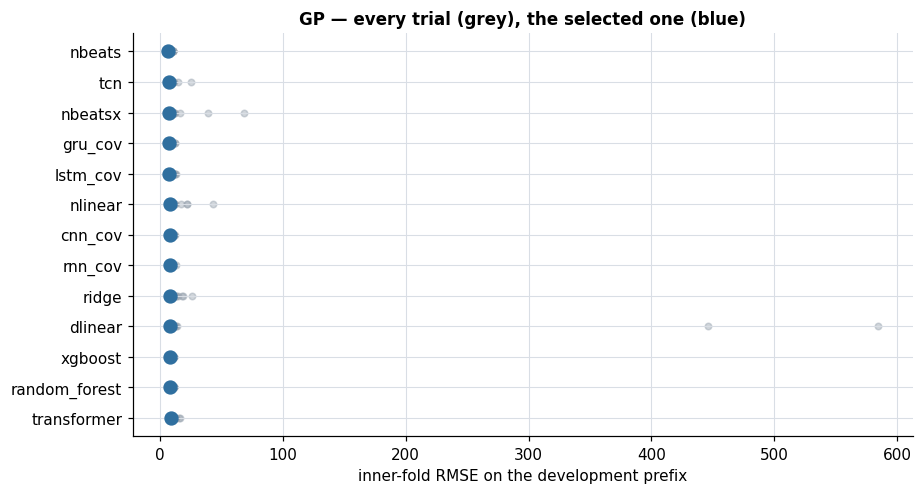

In [5]:

fig, ax = plt.subplots(figsize=(8.5, 4.6))
order = overview.index.tolist()
for i, name in enumerate(order):
    vals = trials.loc[trials["model"] == name, "rmse"].dropna()
    ax.scatter(vals, np.full(len(vals), i), s=18, alpha=0.45, color="#9aa5b1")
    ax.scatter([vals.min()], [i], s=70, color="#2f6f9f", zorder=3)
ax.set_yticks(range(len(order)), order)
ax.invert_yaxis()
ax.set_xlabel("inner-fold RMSE on the development prefix")
ax.set_title(f"{OPERATOR.upper()} — every trial (grey), the selected one (blue)")
fig.tight_layout()
fig.savefig(FIGURES / f"fig16_tuning_search_{OPERATOR}.png", dpi=200, bbox_inches="tight")


## What tuning bought on the held-out folds

The comparison that matters: the selected configuration against the same model at its
defaults, both scored on the eight evaluation folds neither of them saw.

A Diebold–Mariano test accompanies each row. **A model that got worse is reported as
such**, not quietly dropped — a tuned configuration losing on held-out data means the
search overfitted the inner split, and that is worth knowing about the protocol.

In [6]:

gain = pd.read_csv(RESULTS / "tuning_gain.csv")
view = gain[gain["operator"] == OPERATOR].sort_values("gain", ascending=False)
view[["model", "rmse_default", "rmse_tuned", "gain", "p_value",
      "lookback", "covariates", "context"]].round(4)

,model,rmse_default,rmse_tuned,gain,p_value,lookback,covariates,context
3,cnn_cov,14.3110,8.2788,0.4215,0.0000,12,False,rain_only
10,transformer,13.6116,8.6991,0.3609,0.0000,8,False,none
7,dlinear,14.9625,9.6706,0.3537,0.0000,12,True,rain_only
4,lstm_cov,11.9382,8.3700,0.2989,0.0000,8,False,rain_only
8,nlinear,12.2507,8.9074,0.2729,0.0000,24,True,none
9,tcn,11.1267,8.1712,0.2656,0.0000,12,False,rain_only
5,gru_cov,10.6433,8.3286,0.2175,0.0000,48,False,rain_only
12,nbeatsx,9.9485,8.0803,0.1878,0.0000,24,False,none
6,rnn_cov,10.0067,8.2413,0.1764,0.0000,8,False,rain_only
0,ridge,9.0072,8.6875,0.0355,0.0018,24,True,none


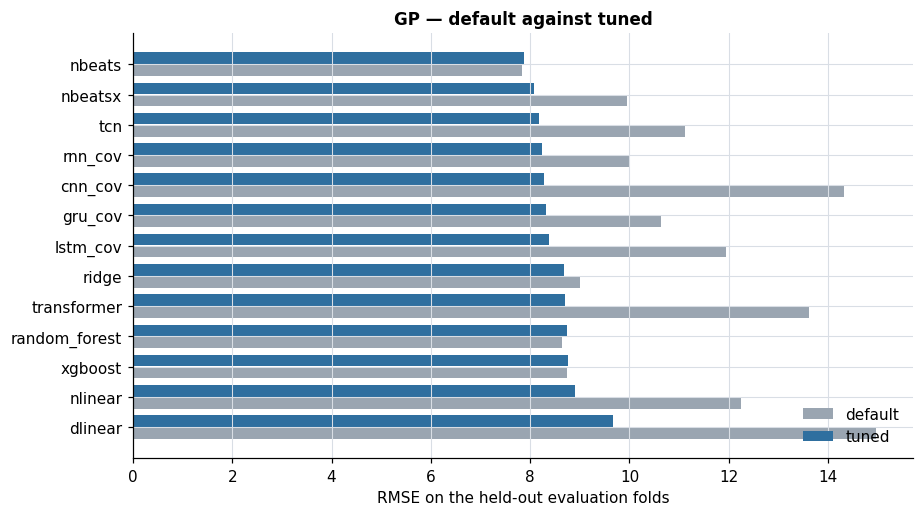

In [7]:

view = view.sort_values("rmse_tuned")
positions = np.arange(len(view))
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.barh(positions + 0.2, view["rmse_default"], 0.38, label="default", color="#9aa5b1")
ax.barh(positions - 0.2, view["rmse_tuned"], 0.38, label="tuned", color="#2f6f9f")
ax.set_yticks(positions, view["model"])
ax.invert_yaxis()
ax.set_xlabel("RMSE on the held-out evaluation folds")
ax.set_title(f"{OPERATOR.upper()} — default against tuned")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIGURES / f"fig17_tuning_gain_{OPERATOR}.png", dpi=200, bbox_inches="tight")


## What the search chose about the features

This is the table that answers the covariate question by measurement rather than by
argument. For each model: how deep a window it wanted, whether it kept the covariate
channels, and which context flags it kept.

In [8]:

both = pd.read_csv(RESULTS / "tuning_gain.csv")
choices = both.pivot_table(index="model", columns="operator",
                           values=["lookback", "covariates"], aggfunc="first")
display(choices)

print("\nHow often each feature choice won, across models and operators:")
print(both["covariates"].value_counts().rename("covariates kept").to_string())
print()
print(both["context"].value_counts().rename("context flags kept").to_string())
print()
print(both["lookback"].value_counts().sort_index().rename("lookback chosen").to_string())

covariates        lookback     
operator              gp   robi       gp robi
model                                        
cnn_cov            False  False       12   12
dlinear             True  False       12   48
gru_cov            False  False       48   48
lstm_cov           False  False        8   48
nbeats             False  False       12    8
nbeatsx            False  False       24    8
nlinear             True  False       24   48
random_forest      False  False       12   36
ridge               True  False       24   48
rnn_cov            False  False        8   48
tcn                False  False       12   12
transformer        False   True        8   48
xgboost             True   True       12   36


How often each feature choice won, across models and operators:
covariates
False    20
True      6

context
rain_only    17
none          6
all           3

lookback
8     5
12    8
24    3
36    2
48    8



## What to take away

1. **Ranking untuned models ranks their defaults.** That was true of every table in this
   project before this notebook, including notebook 08's, and the honest thing is to say
   so rather than to leave it implied.
2. **Selection never touched a test observation**, and the boundary is pinned by two
   gates rather than by care.
3. **The feature set was tuned too**, so "do the covariates help?" has an answer in the
   table above instead of in anyone's judgement.
4. **A negative gain is reported.** If tuning made a model worse on held-out folds, the
   search overfitted its inner split, and that is a finding about the protocol worth
   more than a tidier table.

Notebook 12 puts the tuned field together.